# MAE Pre-training on Cityscapes

## 1 · Imports

In [17]:
import math
import time
import random
from pathlib import Path
from typing  import Optional

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import sys
sys.path.insert(0, "..")

from MAE import MAE, MAEReconstructionLoss
from MAE.configs import mae_vit_base_patch16

## 2 · Config

In [18]:
# ─── Model ────────────────────────────────────────────────────────────────────
IMG_SIZE          = 256
PATCH_SIZE        = 16
IN_CHANNELS       = 3
MASK_RATIO        = 0.75

ENCODER_EMBED_DIM = 768
ENCODER_DEPTH     = 12
ENCODER_NUM_HEADS = 12
DECODER_EMBED_DIM = 512
DECODER_DEPTH     = 8
DECODER_NUM_HEADS = 16
MLP_RATIO         = 4.0
DROPOUT           = 0.0
NORMALIZE_TARGET  = True

# ─── Training ─────────────────────────────────────────────────────────────────
EPOCHS        = 200
WARMUP_EPOCHS = 40
BATCH_SIZE    = 64
NUM_WORKERS   = 4
BASE_LR       = 1.5e-4        # scaled as BASE_LR × batch_size / 256
WEIGHT_DECAY  = 0.05
BETA1, BETA2  = 0.9, 0.95
GRAD_CLIP     = 1.0

LOG_EVERY = 50                # print every N batches
SEED      = 42
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {DEVICE}")
N_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2
print(f"Patches: {N_PATCHES}  ({int(N_PATCHES*(1-MASK_RATIO))} visible / {int(N_PATCHES*MASK_RATIO)} masked)")

Device : cuda
Patches: 256  (64 visible / 192 masked)


## 3 · Reproducibility

In [19]:
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

## 4 · Dataset & DataLoader

In [20]:
import torchvision.transforms as T

train_transform = T.Compose([
    T.Resize(256),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

# ── Drop in your CityscapesDataset here ───────────────────────────────────────
from CityScapes.datasets import CityscapesDataset
train_dataset = CityscapesDataset()

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = NUM_WORKERS,
    pin_memory  = (DEVICE.type == "cuda"),
    drop_last   = True,
)

print(f"Train: {len(train_loader)} batches  ({len(train_dataset)} images)")

Train: 312 batches  (19998 images)


## 5 · Model, Optimiser & Scheduler

In [21]:
model = MAE(
    img_size          = IMG_SIZE,
    patch_size        = PATCH_SIZE,
    in_channels       = IN_CHANNELS,
    encoder_embed_dim = ENCODER_EMBED_DIM,
    encoder_depth     = ENCODER_DEPTH,
    encoder_num_heads = ENCODER_NUM_HEADS,
    decoder_embed_dim = DECODER_EMBED_DIM,
    decoder_depth     = DECODER_DEPTH,
    decoder_num_heads = DECODER_NUM_HEADS,
    mlp_ratio         = MLP_RATIO,
    mask_ratio        = MASK_RATIO,
    dropout           = DROPOUT,
).to(DEVICE)

criterion = MAEReconstructionLoss(
    patch_size       = PATCH_SIZE,
    in_channels      = IN_CHANNELS,
    normalize_target = NORMALIZE_TARGET,
)

print(f"Parameters: {model.num_parameters():,}")

# ── Optimiser (separate weight-decay / no-decay groups) ───────────────────────
effective_lr = BASE_LR * BATCH_SIZE / 256
print(f"Effective LR: {effective_lr:.2e}")

decay, no_decay = [], []
for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if param.ndim <= 1 or name.endswith(".bias"):
        no_decay.append(param)
    else:
        decay.append(param)

optimizer = torch.optim.AdamW(
    [
        {"params": decay,    "weight_decay": WEIGHT_DECAY},
        {"params": no_decay, "weight_decay": 0.0},
    ],
    lr    = effective_lr,
    betas = (BETA1, BETA2),
)

# ── Cosine schedule with linear warmup ────────────────────────────────────────
def lr_lambda(epoch: int) -> float:
    if epoch < WARMUP_EPOCHS:
        return epoch / max(WARMUP_EPOCHS, 1)
    progress = (epoch - WARMUP_EPOCHS) / max(EPOCHS - WARMUP_EPOCHS, 1)
    return max(0.5 * (1.0 + math.cos(math.pi * progress)), 1e-6 / effective_lr)

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

Parameters: 111,655,680
Effective LR: 3.75e-05


## 6 · Training Loop

In [32]:
train_losses = []
lr_history   = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss  = 0.0
    t0          = time.perf_counter()

    for batch_idx, batch in enumerate(train_loader):
        imgs = batch[0].to(DEVICE, non_blocking=True)   # (B, C, H, W)

        pred, mask = model(imgs)                         # (B, N, patch_dim), (B, N)
        loss       = criterion(pred, imgs, mask)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        epoch_loss += loss.item()

        if (batch_idx + 1) % LOG_EVERY == 0:
            print(f"  [{epoch:>4d}/{EPOCHS-1}][{batch_idx+1:>4d}/{len(train_loader)}]"
                  f"  loss={loss.item():.4f}"
                  f"  lr={optimizer.param_groups[0]['lr']:.2e}"
                  f"  {time.perf_counter()-t0:.1f}s")

    scheduler.step()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    lr_history.append(optimizer.param_groups[0]["lr"])

    print(f"Epoch {epoch:>4d}/{EPOCHS-1}  avg_loss={avg_loss:.4f}  "
          f"lr={lr_history[-1]:.2e}  elapsed={time.perf_counter()-t0:.1f}s")

print("\nDone.")

  [   0/199][  50/312]  loss=0.7387  lr=8.44e-06  20.4s
  [   0/199][ 100/312]  loss=0.7092  lr=8.44e-06  40.5s
  [   0/199][ 150/312]  loss=0.7187  lr=8.44e-06  60.6s
  [   0/199][ 200/312]  loss=0.7175  lr=8.44e-06  80.6s
  [   0/199][ 250/312]  loss=0.7131  lr=8.44e-06  100.7s
  [   0/199][ 300/312]  loss=0.7174  lr=8.44e-06  120.8s
Epoch    0/199  avg_loss=0.7193  lr=9.37e-06  elapsed=125.7s
  [   1/199][  50/312]  loss=0.7154  lr=9.37e-06  20.5s
  [   1/199][ 100/312]  loss=0.7278  lr=9.37e-06  40.6s
  [   1/199][ 150/312]  loss=0.7002  lr=9.37e-06  60.7s
  [   1/199][ 200/312]  loss=0.7207  lr=9.37e-06  80.8s
  [   1/199][ 250/312]  loss=0.7136  lr=9.37e-06  100.9s
  [   1/199][ 300/312]  loss=0.7237  lr=9.37e-06  121.0s
Epoch    1/199  avg_loss=0.7158  lr=1.03e-05  elapsed=125.8s
  [   2/199][  50/312]  loss=0.7059  lr=1.03e-05  20.4s
  [   2/199][ 100/312]  loss=0.7155  lr=1.03e-05  40.5s
  [   2/199][ 150/312]  loss=0.7043  lr=1.03e-05  60.6s
  [   2/199][ 200/312]  loss=0.721

KeyboardInterrupt: 

## 7 · Loss & LR Curves

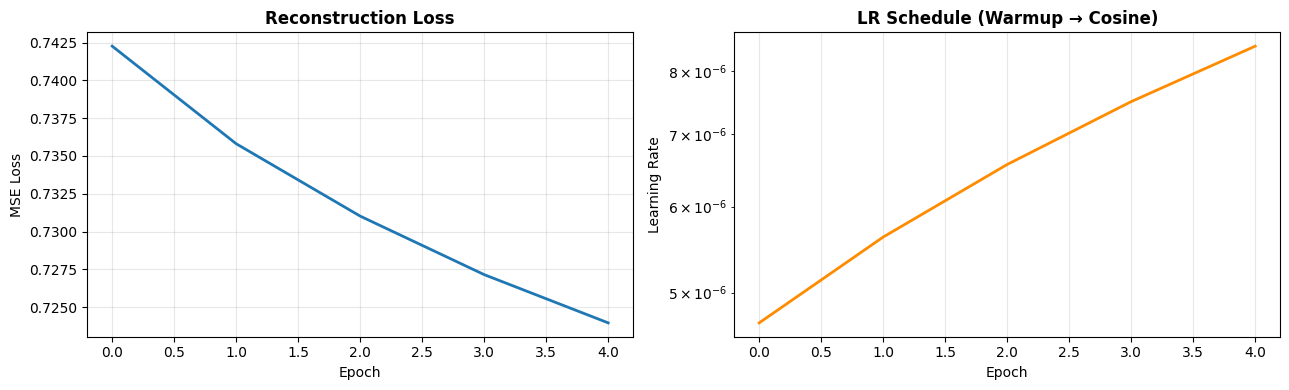

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(train_losses, linewidth=2)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE Loss")
ax1.set_title("Reconstruction Loss", fontweight="bold")
ax1.grid(True, alpha=0.3)

ax2.plot(lr_history, color="darkorange", linewidth=2)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Learning Rate")
ax2.set_title("LR Schedule (Warmup → Cosine)", fontweight="bold")
ax2.set_yscale("log"); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8 · Visualisation

In [34]:
_MEAN = torch.tensor([0.485, 0.456, 0.406])
_STD  = torch.tensor([0.229, 0.224, 0.225])

def denormalize(img: torch.Tensor) -> np.ndarray:
    """(C, H, W) tensor → (H, W, 3) uint8 numpy array."""
    img = img.detach().cpu().float()
    img = img * _STD[:, None, None] + _MEAN[:, None, None]
    return (img.clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype(np.uint8)


def make_masked_image(img: torch.Tensor, mask: torch.Tensor) -> np.ndarray:
    """Greys out the masked patches in the original image."""
    G = img.shape[-1] // PATCH_SIZE
    pixel_mask = (mask.reshape(G, G)
                      .repeat_interleave(PATCH_SIZE, 0)
                      .repeat_interleave(PATCH_SIZE, 1))   # (H, W)
    out = denormalize(img).astype(float) / 255.0
    out = np.where(pixel_mask.cpu().numpy()[..., None], 0.5, out)
    return (out * 255).astype(np.uint8)


def make_reconstruction(
    pred: torch.Tensor,   # (N, patch_dim)
    img:  torch.Tensor,   # (C, H, W)
    mask: torch.Tensor,   # (N,)
) -> np.ndarray:
    """
    Blends decoder predictions (masked patches) with the original (visible patches).
    Reverses the per-patch normalisation applied during the loss computation.
    """
    G = img.shape[-1] // PATCH_SIZE
    N = G * G

    # Patchify original → (N, C*P*P)
    orig = img.reshape(IN_CHANNELS, G, PATCH_SIZE, G, PATCH_SIZE)
    orig = orig.permute(1, 3, 2, 4, 0).reshape(N, -1)   # (N, patch_dim)

    # Reverse per-patch normalisation on the predictions
    mean = orig.mean(dim=-1, keepdim=True)
    std  = orig.var( dim=-1, keepdim=True, unbiased=False).sqrt() + 1e-6
    pred_denorm = (pred.cpu() * std + mean).clamp(-3, 3)

    # Paste predictions only at masked positions
    combined                  = orig.clone()
    combined[mask.bool().cpu()] = pred_denorm[mask.bool().cpu()]

    # (N, patch_dim) → (H, W, C)
    combined = combined.reshape(G, G, PATCH_SIZE, PATCH_SIZE, IN_CHANNELS)
    combined = combined.permute(0, 2, 1, 3, 4).reshape(
        G * PATCH_SIZE, G * PATCH_SIZE, IN_CHANNELS
    ).numpy()

    combined = combined * _STD.numpy() + _MEAN.numpy()
    return (np.clip(combined, 0, 1) * 255).astype(np.uint8)


@torch.no_grad()
def visualise(num_samples: int = 4):
    model.eval()

    imgs = next(iter(train_loader))[0][:num_samples].to(DEVICE)
    pred, mask = model(imgs)

    fig, axes = plt.subplots(num_samples, 3, figsize=(11, 3.5 * num_samples), squeeze=False)
    for col, title in enumerate(["Original", "Masked input", "Reconstruction"]):
        axes[0][col].set_title(title, fontsize=12, fontweight="bold")

    for i in range(num_samples):
        orig_np  = denormalize(imgs[i].cpu())
        mask_np  = make_masked_image(imgs[i].cpu(), mask[i].cpu())
        recon_np = make_reconstruction(pred[i].cpu(), imgs[i].cpu(), mask[i].cpu())

        for col, im in enumerate([orig_np, mask_np, recon_np]):
            axes[i][col].imshow(im)
            axes[i][col].axis("off")

        # Draw patch grid on the masked panel
        G = IMG_SIZE // PATCH_SIZE
        for g in range(G + 1):
            o = g * PATCH_SIZE
            axes[i][1].axhline(o - 0.5, color="white", lw=0.4, alpha=0.5)
            axes[i][1].axvline(o - 0.5, color="white", lw=0.4, alpha=0.5)

    plt.tight_layout()
    plt.show()
    model.train()

## 9 · Run Visualisation

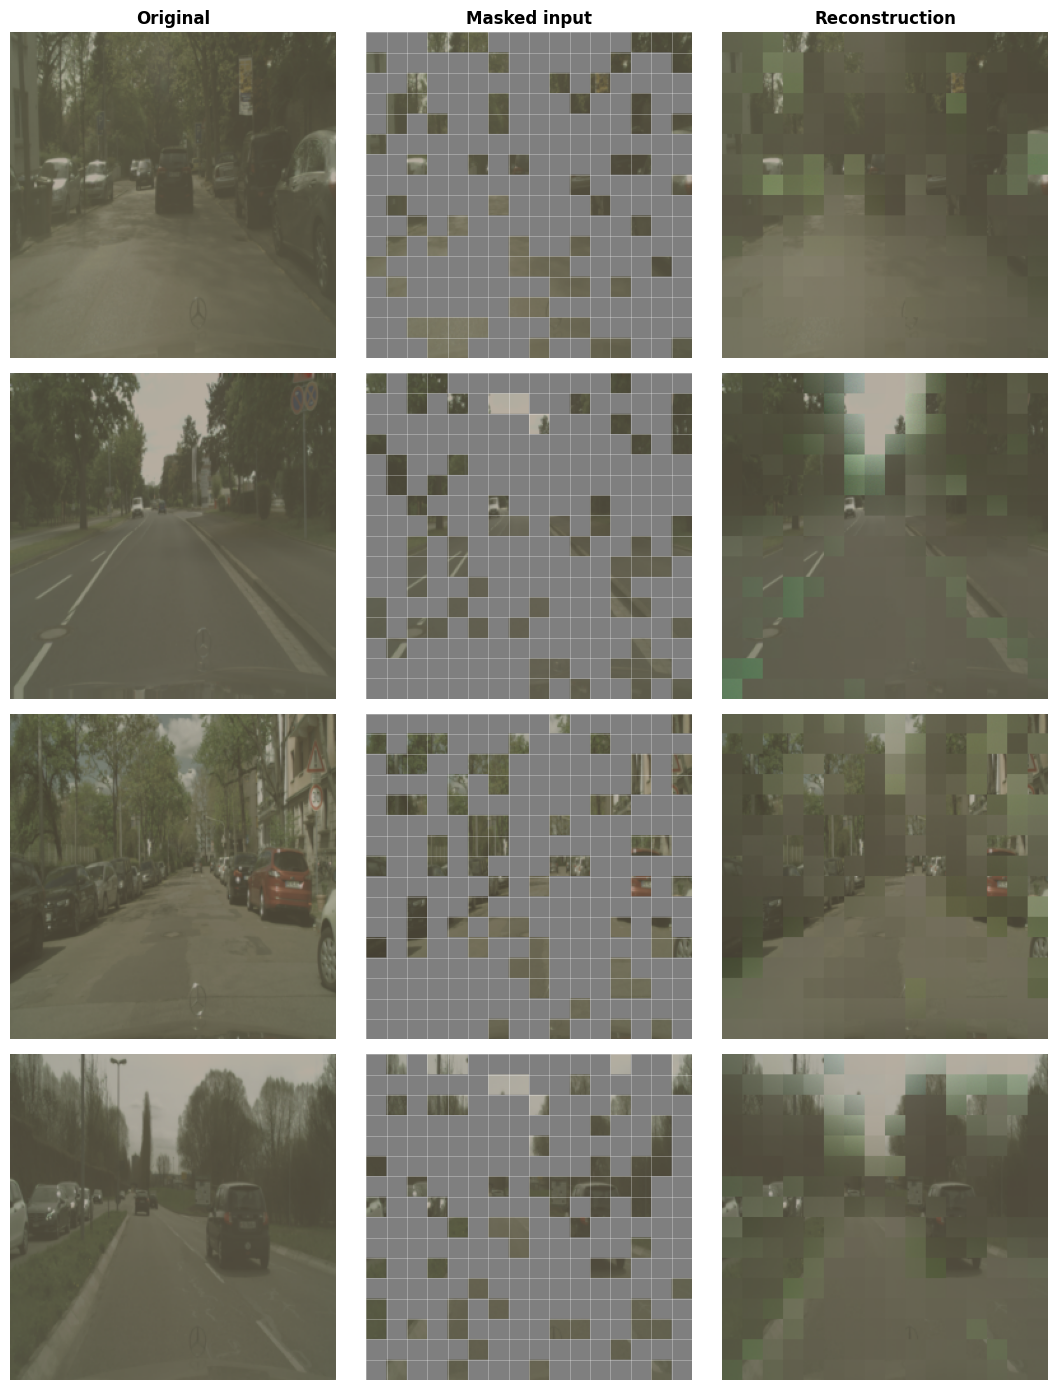

In [35]:
visualise(num_samples=4)